开始t-SNE分析（带KDE热图背景和色阶图例）...
请确保已安装必要的库：
pip install pandas numpy scikit-learn matplotlib seaborn openpyxl xlrd scipy
------------------------------------------------------------
创建目录: D:\文成数据库\t-SNE6
分析KQ（断裂韧性）数据集
KQ数据集包含 209 个样本
识别到的元素列: ['Nb', 'Si', 'Ti', 'Al', 'Cr', 'Hf', 'Zr', 'Mo', 'V', 'W', 'Ta', 'Sn']
数据维度: 训练数据 209 个样本, 优化合金 4 个样本
特征维度: 12 个元素
执行t-SNE分析...


D:\software\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



t-SNE Analysis of Nb-Si Alloys (KQ Dataset) - 坐标轴范围:
  横坐标 (t-SNE Component 1): [-24.084, 25.776]
  纵坐标 (t-SNE Component 2): [-24.216, 26.461]


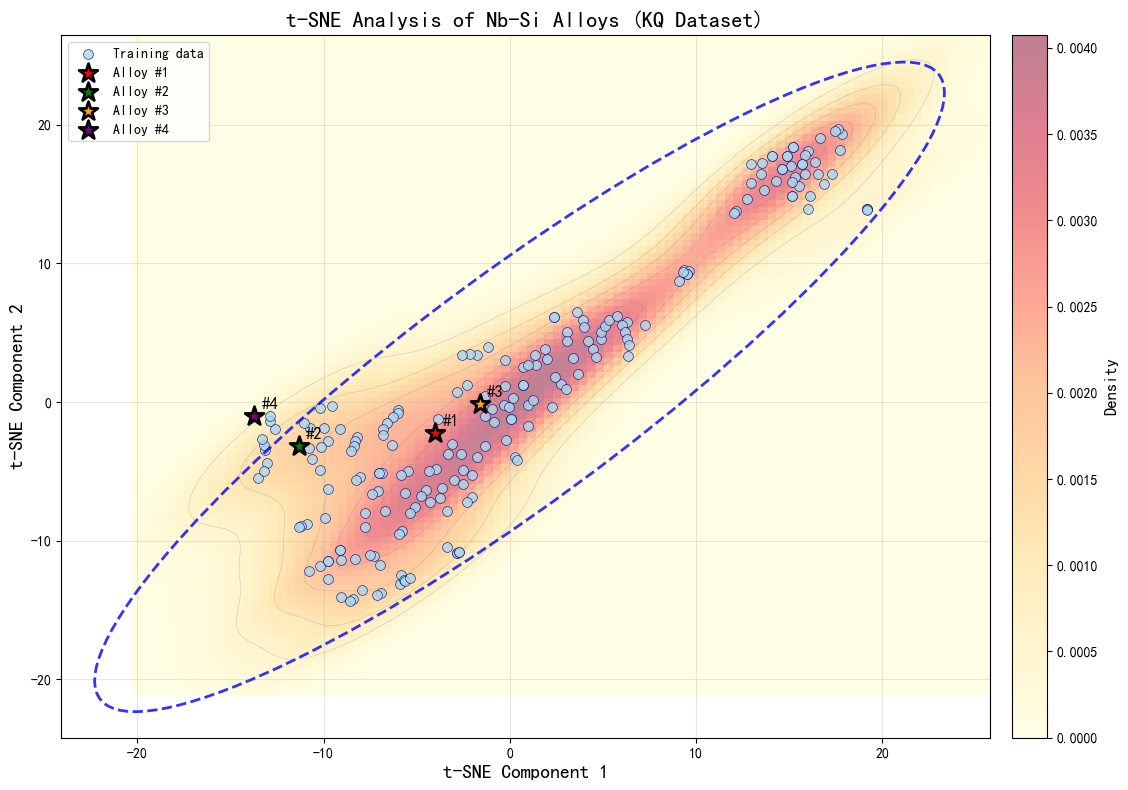

t-SNE数据已保存到: D:\文成数据库\t-SNE6\t-SNE_results_KQ.xlsx

优化合金到训练数据的最小距离分析:
--------------------------------------------------
合金 #1:
  - 到最近训练数据点的距离: 1.074
  - 到训练数据的平均距离: 11.637
  - 位置: 在训练数据分布范围之内
合金 #2:
  - 到最近训练数据点的距离: 0.541
  - 到训练数据的平均距离: 14.911
  - 位置: 在训练数据分布范围之内
合金 #3:
  - 到最近训练数据点的距离: 0.655
  - 到训练数据的平均距离: 11.378
  - 位置: 在训练数据分布范围之内
合金 #4:
  - 到最近训练数据点的距离: 0.839
  - 到训练数据的平均距离: 16.831
  - 位置: 在训练数据分布范围之内
--------------------------------------------------

分析HTC（高温压缩）数据集
HTC数据集包含 34 个样本
识别到的元素列: ['Nb', 'Si', 'Ti', 'Al', 'Cr', 'Hf', 'Zr', 'Mo', 'Fe', 'B', 'V']
数据维度: 训练数据 34 个样本, 优化合金 4 个样本
特征维度: 11 个元素
执行t-SNE分析...


D:\software\anaconda\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



t-SNE Analysis of Nb-Si Alloys (HTC Dataset) - 坐标轴范围:
  横坐标 (t-SNE Component 1): [2.455, 4.794]
  纵坐标 (t-SNE Component 2): [-7.957, -3.071]


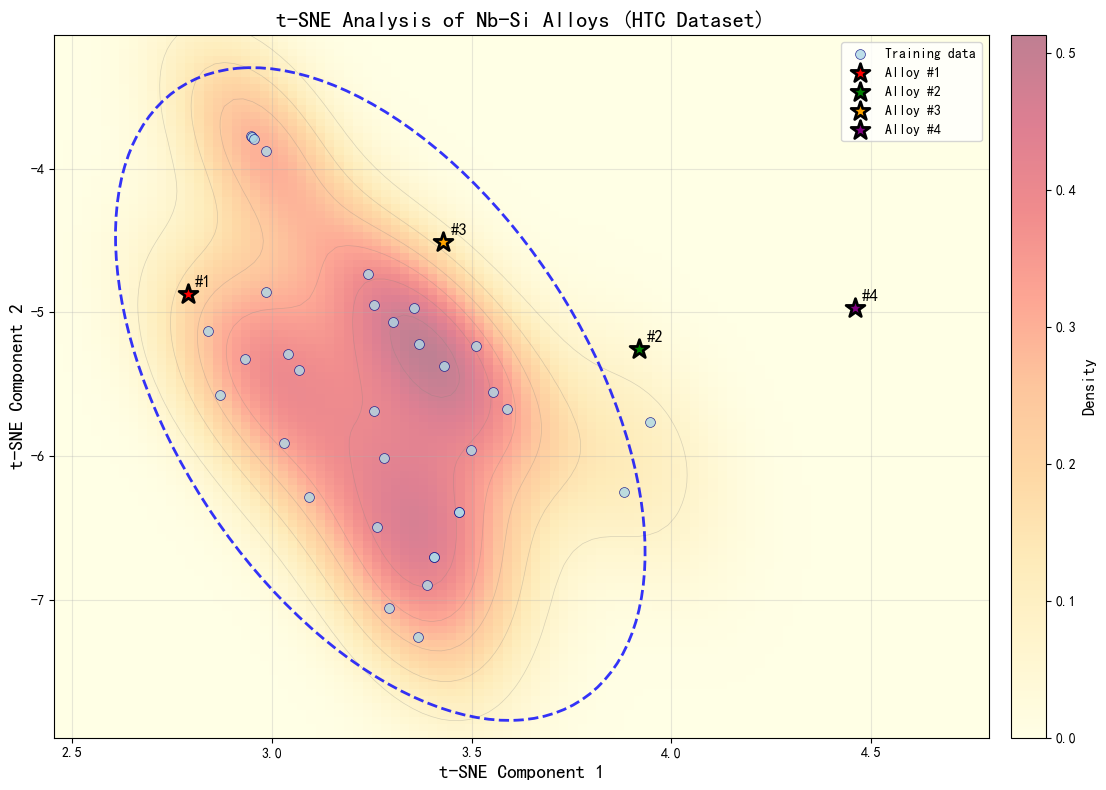

t-SNE数据已保存到: D:\文成数据库\t-SNE6\t-SNE_results_HTC.xlsx

优化合金到训练数据的最小距离分析:
--------------------------------------------------
合金 #1:
  - 到最近训练数据点的距离: 0.195
  - 到训练数据的平均距离: 1.132
  - 位置: 在训练数据分布范围之内
合金 #2:
  - 到最近训练数据点的距离: 0.409
  - 到训练数据的平均距离: 1.099
  - 位置: 在训练数据分布范围之内
合金 #3:
  - 到最近训练数据点的距离: 0.291
  - 到训练数据的平均距离: 1.280
  - 位置: 在训练数据分布范围之内
合金 #4:
  - 到最近训练数据点的距离: 0.945
  - 到训练数据的平均距离: 1.586
  - 位置: 在训练数据分布范围之内
--------------------------------------------------
- t-SNE_Summary.xlsx: 汇总信息和优化合金成分

组合图 - 坐标轴范围:
  KQ数据集:
    横坐标 (t-SNE Component 1): [-24.084, 25.776]
    纵坐标 (t-SNE Component 2): [-24.216, 26.461]
  HTC数据集:
    横坐标 (t-SNE Component 1): [2.455, 4.794]
    纵坐标 (t-SNE Component 2): [-7.957, -3.071]
组合图已保存到: D:\文成数据库\t-SNE6\t-SNE_Combined_plot.png

重要说明：
KQ数据集元素: Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, V, W, Ta, Sn
HTC数据集元素: Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, Fe, B, V
优化合金元素: Nb, Si, Ti, Al, Cr, Hf, Zr, V

由于两个数据集包含的元素不同，t-SNE分析是分别进行的。
每个分析只考虑该数据集中存在的元素，这可能影响跨数据集的比较。

分析完成！所有文件已保存到: D:\文成数据库\t

In [9]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
import os

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 'Arial Unicode MS' for Mac
plt.rcParams['axes.unicode_minus'] = False

# 定义4个优化合金的成分数据
optimized_alloys = {
    '#1': {'Nb': 100-12.26-21.35-1.98-1.96-0.51-4.34-4.35, 'Si': 12.26, 'Ti': 21.35, 
           'Al': 1.98, 'Cr': 1.96, 'Hf': 0.51, 'Zr': 4.34, 'V': 4.35},
    '#2': {'Nb': 100-15.06-26.16-1.97-1.98-0.71-4.64, 'Si': 15.06, 'Ti': 26.16, 
           'Al': 1.97, 'Cr': 1.98, 'Hf': 0.71, 'Zr': 4.64, 'V': 0},
    '#3': {'Nb': 100-14.51-25.72-1.98-1.87-0.52, 'Si': 14.51, 'Ti': 25.72, 
           'Al': 1.98, 'Cr': 1.87, 'Hf': 0.52, 'Zr': 0, 'V': 0},
    '#4': {'Nb': 100-12.59-35-1.77-2.58, 'Si': 12.59, 'Ti': 35, 
           'Al': 1.77, 'Cr': 2.58, 'Hf': 0, 'Zr': 0, 'V': 0}
}

def load_and_process_data(file_path, sheet_name=0):
    """加载并处理Excel数据"""
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df

def extract_composition_features(df, element_columns=None):
    """提取成分特征"""
    # 自动识别数据中的元素列
    # 常见的元素符号列表
    common_elements = ['Nb', 'Si', 'Ti', 'Al', 'Cr', 'Hf', 'Zr', 'V', 'Mo', 'W', 'Ta', 'B', 'Ge', 
                      'Fe', 'Sn', 'Co', 'Ni', 'Cu', 'Y', 'Re', 'Ru', 'C', 'N', 'O']
    
    # 从数据框中识别元素列
    element_cols = []
    for col in df.columns:
        if col in common_elements:
            element_cols.append(col)
    
    print(f"识别到的元素列: {element_cols}")
    
    # 提取成分数据
    composition_data = pd.DataFrame()
    for elem in element_cols:
        composition_data[elem] = df[elem].fillna(0)
    
    return composition_data, element_cols

def add_optimized_alloys(composition_data, element_cols):
    """添加优化合金数据"""
    # 创建优化合金的DataFrame
    opt_df = pd.DataFrame(optimized_alloys).T
    
    # 检查优化合金中是否有训练数据中不存在的元素
    missing_elements = []
    for elem in opt_df.columns:
        if elem not in element_cols and opt_df[elem].sum() > 0:
            missing_elements.append(elem)
    
    if missing_elements:
        print(f"警告: 优化合金包含训练数据中不存在的元素: {missing_elements}")
        print("这些元素将被忽略，可能影响t-SNE分析的准确性！")
    
    # 确保优化合金数据与训练数据有相同的列
    # 只保留训练数据中存在的元素
    for col in element_cols:
        if col not in opt_df.columns:
            opt_df[col] = 0
    
    # 只选择训练数据中存在的元素列
    opt_df = opt_df[element_cols]
    
    # 添加标签
    labels = ['Training'] * len(composition_data) + ['Optimized'] * len(opt_df)
    alloy_names = [''] * len(composition_data) + list(optimized_alloys.keys())
    
    # 合并数据
    all_data = pd.concat([composition_data, opt_df], ignore_index=True)
    
    print(f"数据维度: 训练数据 {len(composition_data)} 个样本, 优化合金 {len(opt_df)} 个样本")
    print(f"特征维度: {len(element_cols)} 个元素")
    
    return all_data, labels, alloy_names

def perform_tsne(data, perplexity=30, n_iter=1000, random_state=42):
    """执行t-SNE降维"""
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, 
                random_state=random_state, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(data)
    return tsne_results

def plot_kde_heatmap(ax, points, extent, resolution=100):
    """在指定的axis上绘制KDE热图"""
    if len(points) < 2:
        return None
    
    # 计算KDE
    kde = gaussian_kde(points.T)
    
    # 创建网格
    x_min, x_max, y_min, y_max = extent
    xx, yy = np.mgrid[x_min:x_max:complex(0, resolution), 
                      y_min:y_max:complex(0, resolution)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # 计算KDE值
    f = np.reshape(kde(positions).T, xx.shape)
    
    # 绘制热图
    im = ax.imshow(f.T, extent=extent, origin='lower', 
                   cmap='YlOrRd', alpha=0.5, aspect='auto')
    
    # 添加等高线（可选）
    ax.contour(xx, yy, f, colors='gray', alpha=0.3, linewidths=0.5)
    
    return im

def plot_tsne_results(tsne_results, labels, alloy_names, title, save_path=None):
    """绘制t-SNE结果（带KDE热图背景）"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 分离训练数据和优化合金数据
    training_mask = np.array(labels) == 'Training'
    optimized_mask = np.array(labels) == 'Optimized'
    
    # 获取训练数据点
    training_points = tsne_results[training_mask]
    
    # 计算绘图范围
    im = None
    if len(training_points) > 0:
        margin = 0.2
        x_range = tsne_results[:, 0].max() - tsne_results[:, 0].min()
        y_range = tsne_results[:, 1].max() - tsne_results[:, 1].min()
        extent = [tsne_results[:, 0].min() - margin * x_range,
                  tsne_results[:, 0].max() + margin * x_range,
                  tsne_results[:, 1].min() - margin * y_range,
                  tsne_results[:, 1].max() + margin * y_range]
        
        # 绘制KDE热图（作为背景）
        if len(training_points) > 10:  # 只有足够的点才绘制KDE
            im = plot_kde_heatmap(ax, training_points, extent)
    
    # 绘制训练数据
    ax.scatter(tsne_results[training_mask, 0], tsne_results[training_mask, 1], 
               c='lightblue', alpha=0.8, s=50, label='Training data', 
               edgecolors='navy', linewidth=0.5, zorder=5)
    
    # 绘制优化合金
    colors = ['red', 'green', 'orange', 'purple']
    for i, (idx, name) in enumerate(zip(np.where(optimized_mask)[0], 
                                       [n for n, m in zip(alloy_names, optimized_mask) if m])):
        ax.scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                  c=colors[i], s=200, marker='*', label=f'Alloy {name}', 
                  edgecolors='black', linewidth=2, zorder=10)
        
        # 添加标签
        ax.annotate(name, (tsne_results[idx, 0], tsne_results[idx, 1]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=12, 
                   fontweight='bold', zorder=15)
    
    # 添加置信椭圆（95%置信区间）
    if len(training_points) > 2:
        cov = np.cov(training_points.T)
        mean = np.mean(training_points, axis=0)
        
        # 计算椭圆参数
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(5.991 * eigenvalues)  # 95% confidence
        
        ellipse = Ellipse(mean, width, height, angle=angle, 
                         facecolor='none', edgecolor='blue', 
                         linestyle='--', linewidth=2, alpha=0.8, zorder=6)
        ax.add_patch(ellipse)
    
    ax.set_xlabel('t-SNE Component 1', fontsize=14)
    ax.set_ylabel('t-SNE Component 2', fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, zorder=1)
    
    # 添加色阶图例
    if im is not None:
        cbar = plt.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label('Density', fontsize=12)
        cbar.ax.tick_params(labelsize=10)
    
    # 调整布局
    plt.tight_layout()
    
    # 打印坐标轴范围
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    print(f"\n{title} - 坐标轴范围:")
    print(f"  横坐标 (t-SNE Component 1): [{xlim[0]:.3f}, {xlim[1]:.3f}]")
    print(f"  纵坐标 (t-SNE Component 2): [{ylim[0]:.3f}, {ylim[1]:.3f}]")
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig, ax

def plot_tsne_on_axis(ax, tsne_results, labels, alloy_names, title):
    """在指定的axis上绘制t-SNE结果（带KDE热图背景）"""
    # 分离训练数据和优化合金数据
    training_mask = np.array(labels) == 'Training'
    optimized_mask = np.array(labels) == 'Optimized'
    
    # 获取训练数据点
    training_points = tsne_results[training_mask]
    
    # 计算绘图范围
    im = None
    if len(training_points) > 0:
        margin = 0.2
        x_range = tsne_results[:, 0].max() - tsne_results[:, 0].min()
        y_range = tsne_results[:, 1].max() - tsne_results[:, 1].min()
        extent = [tsne_results[:, 0].min() - margin * x_range,
                  tsne_results[:, 0].max() + margin * x_range,
                  tsne_results[:, 1].min() - margin * y_range,
                  tsne_results[:, 1].max() + margin * y_range]
        
        # 绘制KDE热图（作为背景）
        if len(training_points) > 10:  # 只有足够的点才绘制KDE
            im = plot_kde_heatmap(ax, training_points, extent, resolution=80)
    
    # 绘制训练数据
    ax.scatter(tsne_results[training_mask, 0], tsne_results[training_mask, 1], 
               c='lightblue', alpha=0.8, s=50, label='Training data', 
               edgecolors='navy', linewidth=0.5, zorder=5)
    
    # 绘制优化合金
    colors = ['red', 'green', 'orange', 'purple']
    for i, (idx, name) in enumerate(zip(np.where(optimized_mask)[0], 
                                       [n for n, m in zip(alloy_names, optimized_mask) if m])):
        ax.scatter(tsne_results[idx, 0], tsne_results[idx, 1], 
                  c=colors[i], s=200, marker='*', label=f'Alloy {name}', 
                  edgecolors='black', linewidth=2, zorder=10)
        
        # 添加标签
        ax.annotate(name, (tsne_results[idx, 0], tsne_results[idx, 1]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=10, 
                   fontweight='bold', zorder=15)
    
    # 添加置信椭圆（95%置信区间）
    if len(training_points) > 2:
        cov = np.cov(training_points.T)
        mean = np.mean(training_points, axis=0)
        
        # 计算椭圆参数
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(5.991 * eigenvalues)  # 95% confidence
        
        ellipse = Ellipse(mean, width, height, angle=angle, 
                         facecolor='none', edgecolor='blue', 
                         linestyle='--', linewidth=2, alpha=0.8, zorder=6)
        ax.add_patch(ellipse)
    
    ax.set_xlabel('t-SNE Component 1', fontsize=12)
    ax.set_ylabel('t-SNE Component 2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3, zorder=1)
    
    # 返回坐标轴范围和图像对象（用于色阶图例）
    return ax.get_xlim(), ax.get_ylim(), im

def analyze_distances(tsne_results, labels, alloy_names):
    """分析优化合金到训练数据的距离"""
    training_mask = np.array(labels) == 'Training'
    optimized_mask = np.array(labels) == 'Optimized'
    
    training_points = tsne_results[training_mask]
    optimized_points = tsne_results[optimized_mask]
    optimized_names = [n for n, m in zip(alloy_names, optimized_mask) if m]
    
    # 计算每个优化合金到最近训练数据点的距离
    print("\n优化合金到训练数据的最小距离分析:")
    print("-" * 50)
    
    for i, name in enumerate(optimized_names):
        distances = np.sqrt(np.sum((training_points - optimized_points[i])**2, axis=1))
        min_dist = np.min(distances)
        avg_dist = np.mean(distances)
        
        print(f"合金 {name}:")
        print(f"  - 到最近训练数据点的距离: {min_dist:.3f}")
        print(f"  - 到训练数据的平均距离: {avg_dist:.3f}")
        
        # 判断是否在训练数据的分布范围内
        training_center = np.mean(training_points, axis=0)
        training_radius = np.max(np.sqrt(np.sum((training_points - training_center)**2, axis=1)))
        opt_to_center = np.sqrt(np.sum((optimized_points[i] - training_center)**2))
        
        if opt_to_center > training_radius:
            print(f"  - 位置: 在训练数据分布范围之外 (探索新区域)")
        else:
            print(f"  - 位置: 在训练数据分布范围之内")
    
    print("-" * 50)

def save_tsne_data(tsne_results, labels, alloy_names, element_cols, save_path, dataset_name):
    """保存t-SNE结果数据到Excel文件"""
    # 创建数据框
    df_results = pd.DataFrame({
        'Sample_ID': [f'Sample_{i+1}' if name == '' else name for i, name in enumerate(alloy_names)],
        'Type': labels,
        't-SNE_Component_1': tsne_results[:, 0],
        't-SNE_Component_2': tsne_results[:, 1]
    })
    
    # 添加元素成分信息（如果需要）
    # 这里可以根据需要添加更多信息
    
    # 分离训练数据和优化合金数据
    training_mask = np.array(labels) == 'Training'
    optimized_mask = np.array(labels) == 'Optimized'
    
    # 计算一些统计信息
    stats_data = []
    optimized_indices = np.where(optimized_mask)[0]
    optimized_names = [n for n, m in zip(alloy_names, optimized_mask) if m]
    
    for i, name in enumerate(optimized_names):
        opt_point = tsne_results[optimized_indices[i]]
        training_points = tsne_results[training_mask]
        
        # 计算距离
        distances = np.sqrt(np.sum((training_points - opt_point)**2, axis=1))
        min_dist = np.min(distances)
        avg_dist = np.mean(distances)
        
        # 判断是否在分布范围内
        training_center = np.mean(training_points, axis=0)
        training_radius = np.max(np.sqrt(np.sum((training_points - training_center)**2, axis=1)))
        opt_to_center = np.sqrt(np.sum((opt_point - training_center)**2))
        
        stats_data.append({
            'Alloy': name,
            'Min_Distance_to_Training': min_dist,
            'Avg_Distance_to_Training': avg_dist,
            'Distance_to_Center': opt_to_center,
            'Training_Radius': training_radius,
            'Within_Training_Distribution': 'Yes' if opt_to_center <= training_radius else 'No'
        })
    
    df_stats = pd.DataFrame(stats_data)
    
    # 保存到Excel
    excel_path = os.path.join(save_path, f't-SNE_results_{dataset_name}.xlsx')
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        df_results.to_excel(writer, sheet_name='t-SNE Coordinates', index=False)
        df_stats.to_excel(writer, sheet_name='Distance Analysis', index=False)
        
        # 添加元素信息
        df_elements = pd.DataFrame({'Elements': element_cols})
        df_elements.to_excel(writer, sheet_name='Element Info', index=False)
    
    print(f"t-SNE数据已保存到: {excel_path}")
    
    return df_results, df_stats

# 主程序
def main():
    # 文件路径
    kq_file = r'D:\文成数据库\Nb-Si数据库6.21.2-成分-性能.xlsx'
    htc_file = r'D:\文成数据库\Nb-Si数据库2.28-高温压缩.xlsx'
    save_dir = r'D:\文成数据库\t-SNE6'
    
    # 创建保存目录
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"创建目录: {save_dir}")
    
    # 分析KQ数据
    print("=" * 60)
    print("分析KQ（断裂韧性）数据集")
    print("=" * 60)
    
    try:
        # 加载KQ数据
        kq_df = load_and_process_data(kq_file)
        print(f"KQ数据集包含 {len(kq_df)} 个样本")
        
        # 提取成分特征
        kq_composition, kq_elements = extract_composition_features(kq_df)
        
        # 添加优化合金
        kq_all_data, kq_labels, kq_names = add_optimized_alloys(kq_composition, kq_elements)
        
        # 执行t-SNE
        print("执行t-SNE分析...")
        kq_tsne = perform_tsne(kq_all_data)
        
        # 绘制结果
        kq_save_path = os.path.join(save_dir, 't-SNE_KQ_plot.png')
        plot_tsne_results(kq_tsne, kq_labels, kq_names, 
                         't-SNE Analysis of Nb-Si Alloys (KQ Dataset)', 
                         kq_save_path)
        
        # 保存t-SNE数据到Excel
        save_tsne_data(kq_tsne, kq_labels, kq_names, kq_elements, save_dir, 'KQ')
        
        # 分析距离
        analyze_distances(kq_tsne, kq_labels, kq_names)
        
    except Exception as e:
        print(f"处理KQ数据时出错: {e}")
        import traceback
        traceback.print_exc()
    
    # 分析HTC数据
    print("\n" + "=" * 60)
    print("分析HTC（高温压缩）数据集")
    print("=" * 60)
    
    try:
        # 加载HTC数据
        htc_df = load_and_process_data(htc_file)
        print(f"HTC数据集包含 {len(htc_df)} 个样本")
        
        # 提取成分特征
        htc_composition, htc_elements = extract_composition_features(htc_df)
        
        # 添加优化合金
        htc_all_data, htc_labels, htc_names = add_optimized_alloys(htc_composition, htc_elements)
        
        # 执行t-SNE
        print("执行t-SNE分析...")
        htc_tsne = perform_tsne(htc_all_data)
        
        # 绘制结果
        htc_save_path = os.path.join(save_dir, 't-SNE_HTC_plot.png')
        plot_tsne_results(htc_tsne, htc_labels, htc_names, 
                         't-SNE Analysis of Nb-Si Alloys (HTC Dataset)', 
                         htc_save_path)
        
        # 保存t-SNE数据到Excel
        save_tsne_data(htc_tsne, htc_labels, htc_names, htc_elements, save_dir, 'HTC')
        
        # 分析距离
        analyze_distances(htc_tsne, htc_labels, htc_names)
        
    except Exception as e:
        print(f"处理HTC数据时出错: {e}")
        import traceback
        traceback.print_exc()
    
    # 创建汇总的Excel文件
    try:
        summary_path = os.path.join(save_dir, 't-SNE_Summary.xlsx')
        with pd.ExcelWriter(summary_path, engine='openpyxl') as writer:
            # 添加说明页
            info_data = {
                'Dataset': ['KQ', 'HTC'],
                'Total_Samples': [len(kq_df) if 'kq_df' in locals() else 0, 
                                 len(htc_df) if 'htc_df' in locals() else 0],
                'Elements': ['Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, V, W, Ta, Sn',
                            'Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, Fe, B, V'],
                'Optimized_Alloys': ['#1, #2, #3, #4', '#1, #2, #3, #4']
            }
            pd.DataFrame(info_data).to_excel(writer, sheet_name='Summary', index=False)
            
            # 添加优化合金成分
            opt_comp_df = pd.DataFrame(optimized_alloys).T
            opt_comp_df.to_excel(writer, sheet_name='Optimized Alloy Compositions')
        
        print(f"- t-SNE_Summary.xlsx: 汇总信息和优化合金成分")
    except:
        pass
    
    # 创建组合图（两个数据集对比）
    try:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        
        # 重新绘制KQ结果到ax1
        kq_xlim, kq_ylim, kq_im = None, None, None
        if 'kq_tsne' in locals():
            kq_xlim, kq_ylim, kq_im = plot_tsne_on_axis(ax1, kq_tsne, kq_labels, kq_names, 
                            't-SNE Analysis of Nb-Si Alloys (KQ Dataset)')
        
        # 重新绘制HTC结果到ax2
        htc_xlim, htc_ylim, htc_im = None, None, None
        if 'htc_tsne' in locals():
            htc_xlim, htc_ylim, htc_im = plot_tsne_on_axis(ax2, htc_tsne, htc_labels, htc_names, 
                            't-SNE Analysis of Nb-Si Alloys (HTC Dataset)')
        
        # 为每个子图添加色阶图例
        if kq_im is not None:
            cbar1 = fig.colorbar(kq_im, ax=ax1, pad=0.02, fraction=0.046)
            cbar1.set_label('Density', fontsize=10)
            cbar1.ax.tick_params(labelsize=8)
        
        if htc_im is not None:
            cbar2 = fig.colorbar(htc_im, ax=ax2, pad=0.02, fraction=0.046)
            cbar2.set_label('Density', fontsize=10)
            cbar2.ax.tick_params(labelsize=8)
        
        plt.tight_layout()
        combined_path = os.path.join(save_dir, 't-SNE_Combined_plot.png')
        plt.savefig(combined_path, dpi=300, bbox_inches='tight')
        
        # 打印组合图的坐标轴范围
        print(f"\n组合图 - 坐标轴范围:")
        if kq_xlim and kq_ylim:
            print(f"  KQ数据集:")
            print(f"    横坐标 (t-SNE Component 1): [{kq_xlim[0]:.3f}, {kq_xlim[1]:.3f}]")
            print(f"    纵坐标 (t-SNE Component 2): [{kq_ylim[0]:.3f}, {kq_ylim[1]:.3f}]")
        if htc_xlim and htc_ylim:
            print(f"  HTC数据集:")
            print(f"    横坐标 (t-SNE Component 1): [{htc_xlim[0]:.3f}, {htc_xlim[1]:.3f}]")
            print(f"    纵坐标 (t-SNE Component 2): [{htc_ylim[0]:.3f}, {htc_ylim[1]:.3f}]")
        
        plt.close()
        print(f"组合图已保存到: {combined_path}")
    except:
        pass
    
    print("\n" + "=" * 60)
    print("重要说明：")
    print("=" * 60)
    print("KQ数据集元素: Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, V, W, Ta, Sn")
    print("HTC数据集元素: Nb, Si, Ti, Al, Cr, Hf, Zr, Mo, Fe, B, V")
    print("优化合金元素: Nb, Si, Ti, Al, Cr, Hf, Zr, V")
    print("\n由于两个数据集包含的元素不同，t-SNE分析是分别进行的。")
    print("每个分析只考虑该数据集中存在的元素，这可能影响跨数据集的比较。")
    
    print(f"\n分析完成！所有文件已保存到: {save_dir}")
    print("\n保存的文件包括：")
    print("- t-SNE_KQ_plot.png: KQ数据集的t-SNE可视化（带KDE热图背景和色阶图例）")
    print("- t-SNE_HTC_plot.png: HTC数据集的t-SNE可视化（带KDE热图背景和色阶图例）")
    print("- t-SNE_Combined_plot.png: 两个数据集的组合对比图（带KDE热图背景和色阶图例）")
    print("- t-SNE_results_KQ.xlsx: KQ数据集的t-SNE坐标和分析结果")
    print("- t-SNE_results_HTC.xlsx: HTC数据集的t-SNE坐标和分析结果")
    print("\n注意：KDE热图显示了训练数据点的密度分布，颜色越深表示数据密度越高。")
    print("色阶图例显示了密度值的范围。")

if __name__ == "__main__":
    print("开始t-SNE分析（带KDE热图背景和色阶图例）...")
    print("请确保已安装必要的库：")
    print("pip install pandas numpy scikit-learn matplotlib seaborn openpyxl xlrd scipy")
    print("-" * 60)
    main()